##### ***多输入通道***
###### 也就是说输入的维度不再是2，而是3，多了一个通道数，这时候也要改变卷积核的通道数，跟输入一样，接着就对应的进行卷积计算求和就得到最终结果
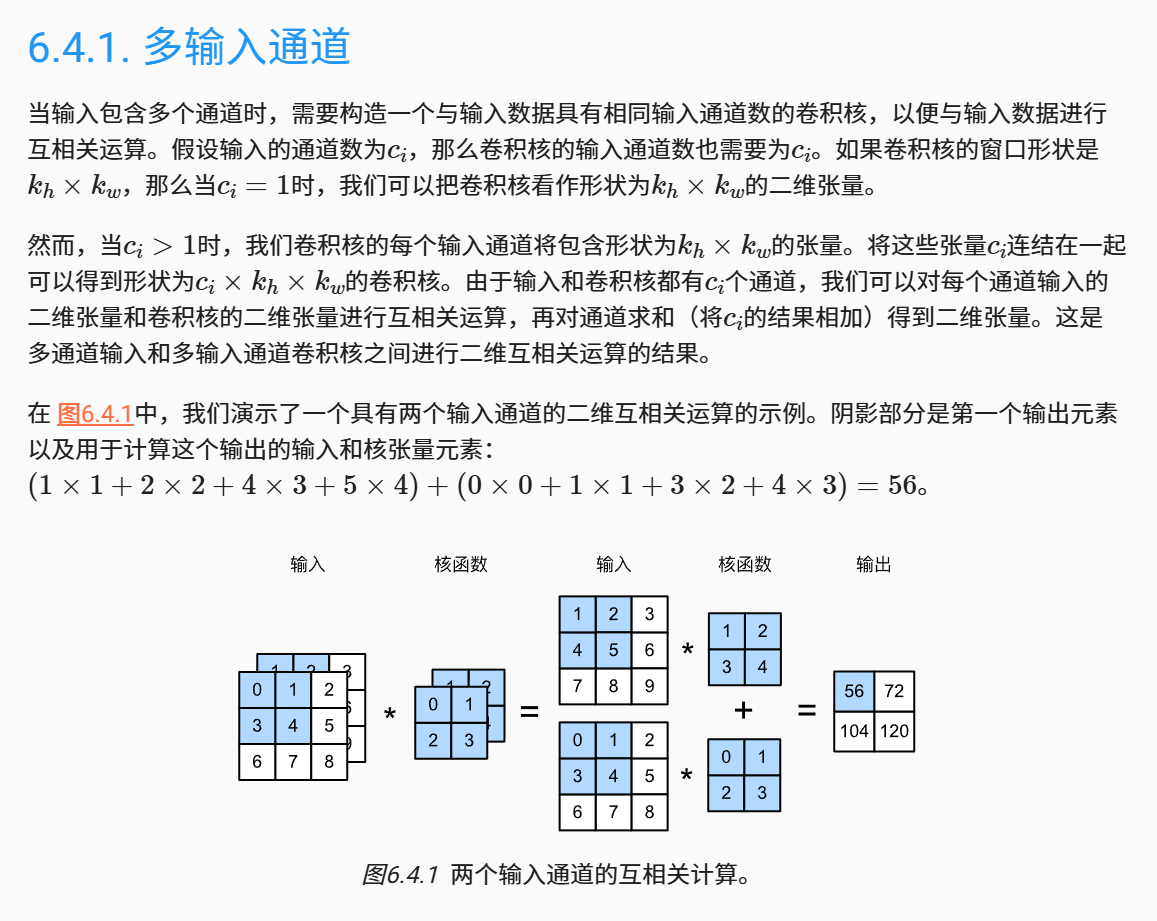
##### ***多输出通道***
###### 多输出通道的情况就是在卷积核上再多加一个输出的维度，在输出前，用这个输出维度分别对输入的每个通道进行卷积计算，最后将所有通道的结果拼接起来就得到了最终的输出
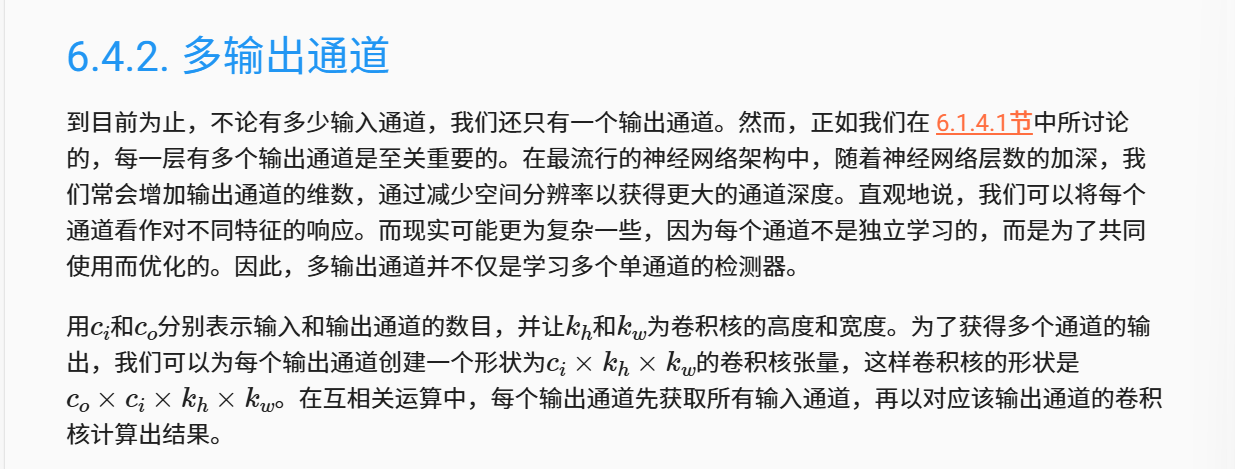
###### 对于多输出的解释：就是说多个输出通道会对应不同的模式，也就是说每个通道由于卷积核的不同，会提取出不同的特征。
###### 对于多输入的解释：就是说多个输入会对应多种特征然后将这些特征组合起来，形成一个新的特征图。

In [1]:
# 多输入通道
import torch
from d2l import torch as d2l

def corr2d_multi_in(X, K): # X: 输入, K: 卷积核
    # 先遍历“X”和“K”的第0个维度（通道维度），再把它们加在一起
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

In [2]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

print(X.shape)
print(K.shape)
corr2d_multi_in(X, K)

torch.Size([2, 3, 3])
torch.Size([2, 2, 2])


tensor([[ 56.,  72.],
        [104., 120.]])

In [3]:
# 多输出通道
def corr2d_multi_in_out(X, K): # X: 输入, K: 卷积核
    # 迭代“K”的第0个维度，每次都对输入“X”执行互相关运算。
    # 最后将所有结果都叠加在一起
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [4]:
K = torch.stack((K, K + 1, K + 2), 0)
print(K.shape)


torch.Size([3, 2, 2, 2])


In [5]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

In [6]:
# 1*1卷积层：也就是点卷积层，看上去似乎没有多大意义，但是实际上它有很多重要的应用。它与全连接很相似，但是由于卷积核的值不同，相当于是将输入进行了加权求和，这样就可以把每个输入特征进行线性变换，从而生成新的特征表示，并且按照不同的权重进行组合，从而得到不同的特征。

In [ ]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0] # 卷积核一般是（输出通道数，输入通道数，1，1）

    X = X.reshape((c_i, h * w)) # 把每个像素点的特征向量拉成一个列向量
    K = K.reshape((c_o, c_i)) # 把卷积核变成一个权重矩阵

    # 全连接层中的矩阵乘法
    Y = torch.matmul(K, X) # (c_o, c_i) @ (c_i, h * w) = (c_o, h * w)
    return Y.reshape((c_o, h, w)) # 把输出的列向量恢复成原来的像素点特征向量

In [10]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6